In [2]:
from src import *

- Initialisation of the hyperparameters 

In [3]:
L = 40  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

Lambda grid: 100%|██████████| 41/41 [00:00<00:00, 44.88it/s]


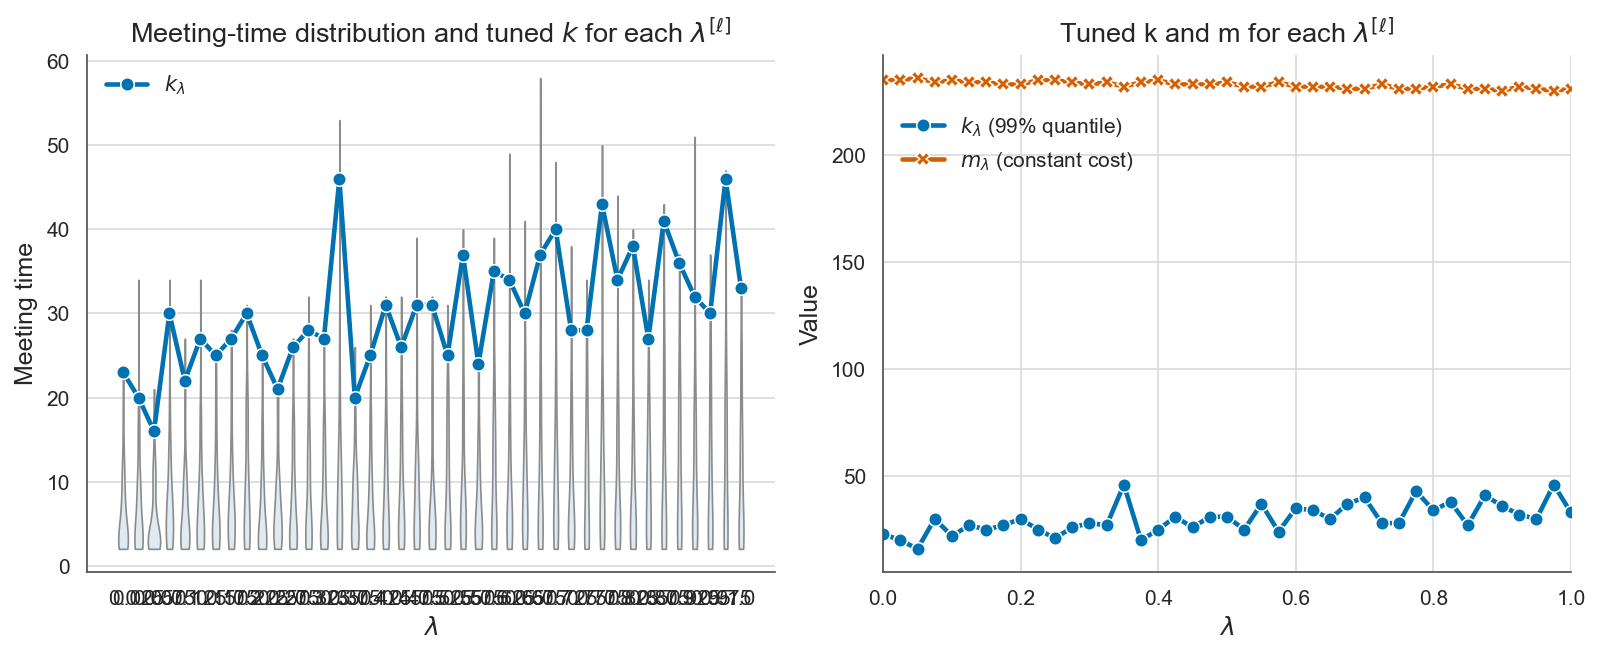

In [4]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 41/41 [00:12<00:00,  3.37it/s]


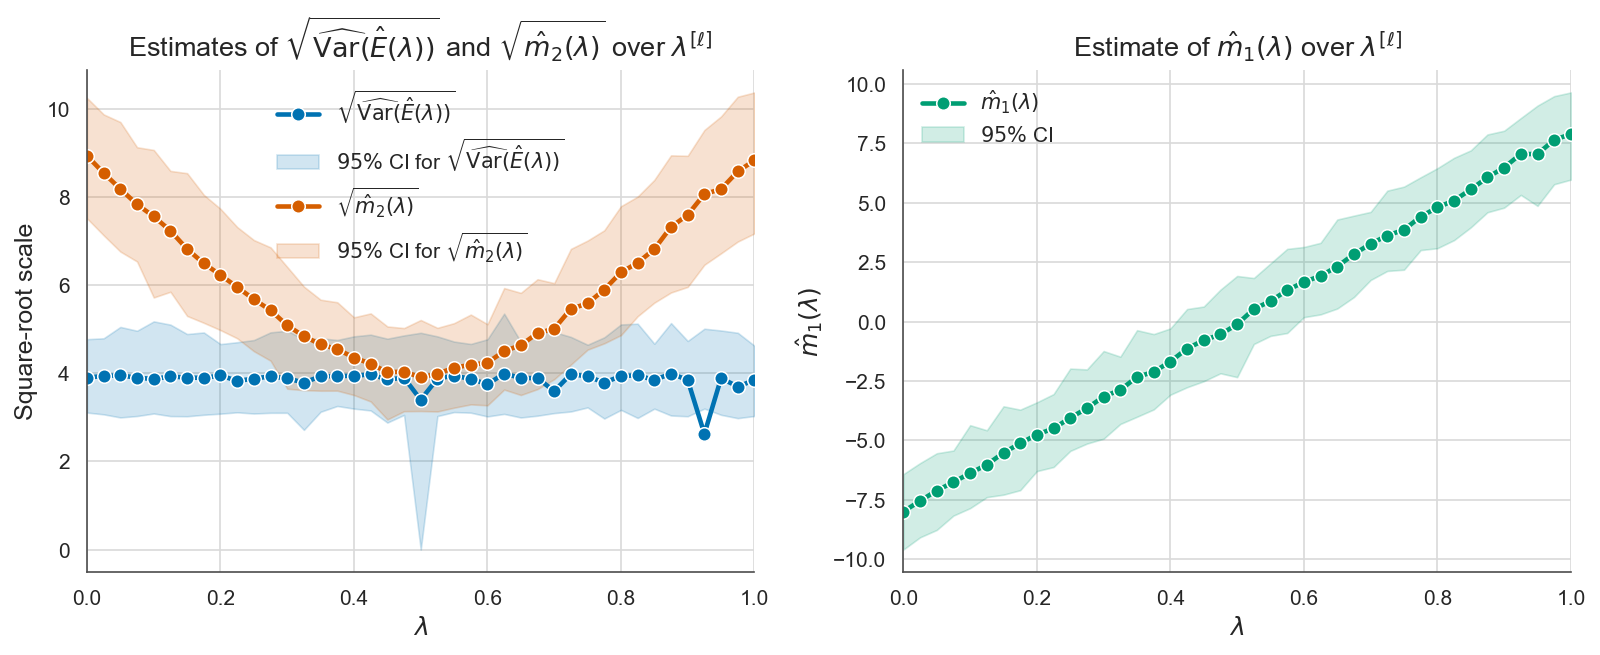

In [5]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag)

### Now try various startified estimators 

In [6]:


def random_budget_allocation(L, M):
    if M < L:
        raise ValueError("M must be at least L so each bin gets at least one sample.")

    # Give one sample to each bin, then distribute the remaining budget randomly.
    budget = np.ones(L, dtype=int)
    remaining = M - L

    if remaining > 0:
        extra = np.random.multinomial(remaining, np.ones(L) / L)
        budget += extra

    return budget



- For a fixed budget of M

In [8]:
M = 40
L = 20
L_initial = M//2
L_final = M 
M_budget = random_budget_allocation(L, M)
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag)


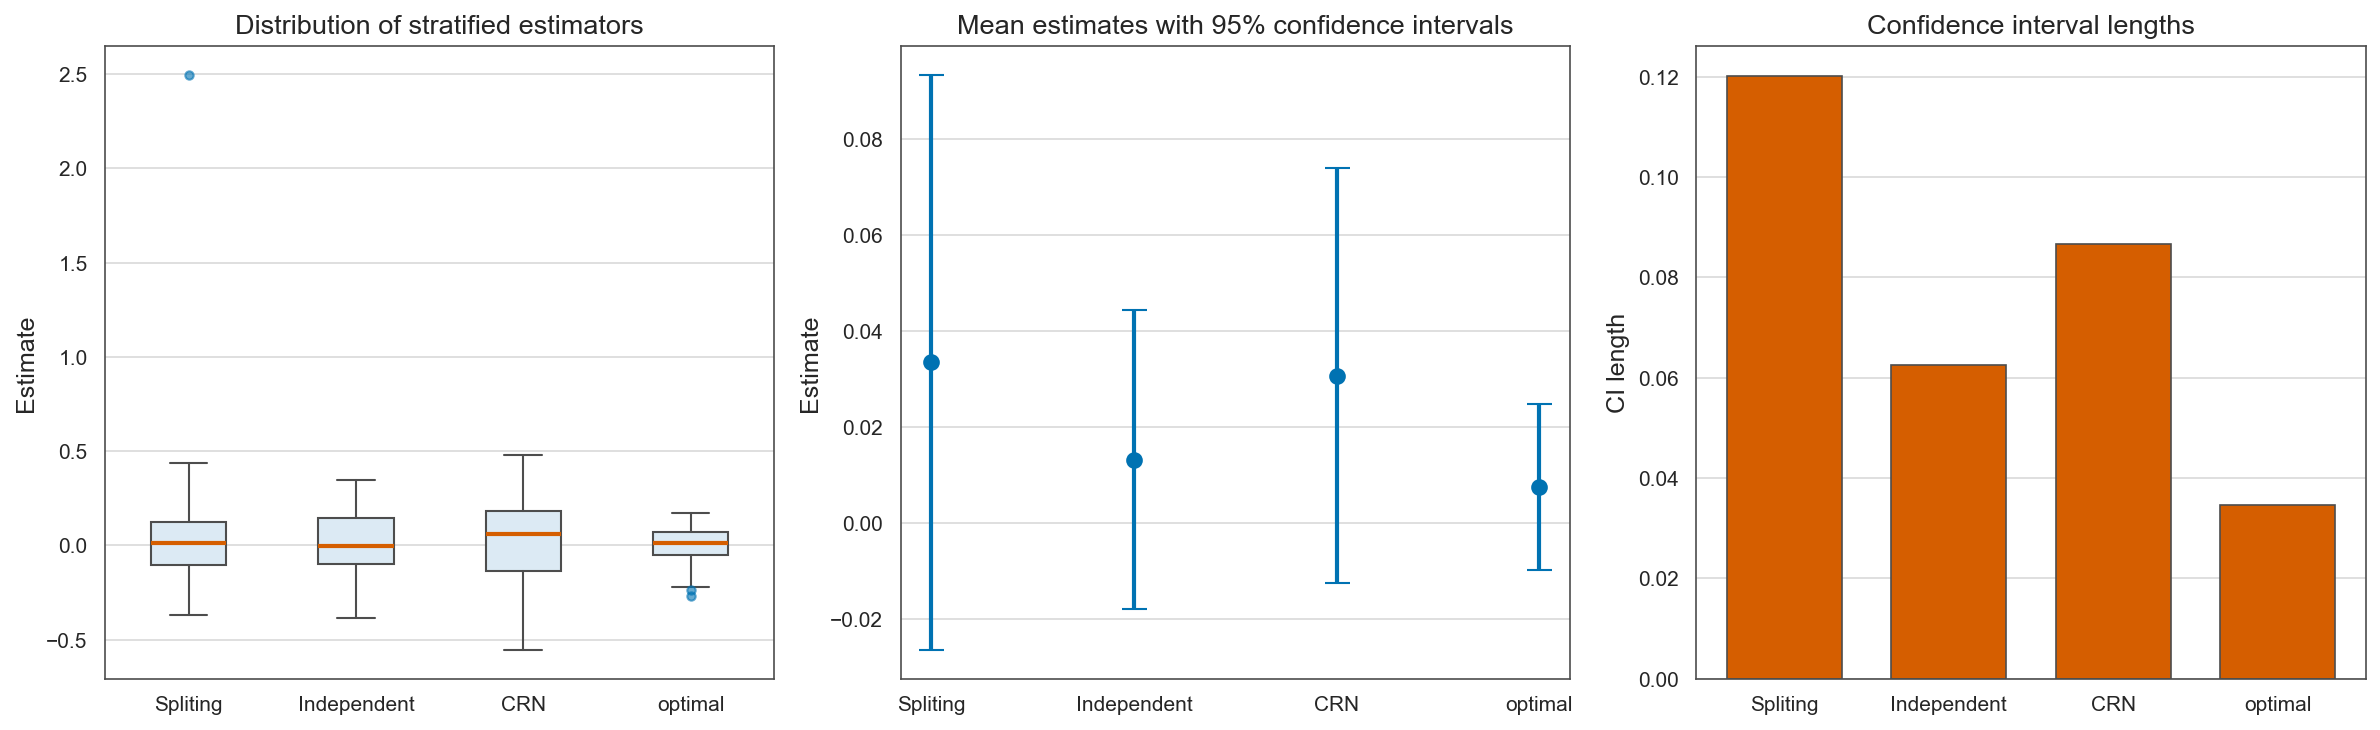

Spliting: CI length = 0.120074
Independent: CI length = 0.062459
CRN: CI length = 0.086640
optimal: CI length = 0.034685


In [ ]:
estimators = [
    lambda: stratified_estimator_splitting(L_final, estimator, initial_L=L_initial, n_samples=5),
    lambda: stratified_estimator_indepdent(L, M_budget, estimator),
    lambda: stratified_estimator_crn(L, M_budget, estimator),
    lambda: optimal_startified_estimator(0.5, M, estimator),
    lambda: propo_startified_estimator(0.5, M, estimator),
]

labels = ["Spliting", "Independent", "CRN", "optimal", "proportinal"]

xp1 = plot_estimators_box_CI(
    estimators,
    labels,
    nrep=100,
    ci_level=0.95,
)


In [ ]:
xp2 = plot_estimators_histograms(estimators,
    labels,
    nrep=200,
    bins=25,
)

In [ ]:
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag)


In [ ]:
res = plot_mse_proposed_vs_splitting(
    alpha=0.5,
    estimator=estimator,
    M_min=50,
    M_max=200,
    M_step=10,
    nrep=20,
    initial_L=10,
)
